In [1]:
import os
import json
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq

In [2]:
%pip install langgraph langchain-groq python-dotenv matplotlib

Note: you may need to restart the kernel to use updated packages.


c:\Users\puroh\Desktop\langgraph-tutoril\.venv\Scripts\python.exe: No module named pip


In [3]:
from dotenv import load_dotenv
load_dotenv()

model = ChatGroq(model="llama-3.3-70b-versatile")

def generate_content(prompt: str) -> str:
    """Helper function to generate content using Groq"""
    response = model.invoke(prompt)
    return response.content.strip()

test_response = generate_content("Say hello in one sentence.")
print(f"Groq API working: {test_response}")

Groq API working: Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


In [4]:
class AgentState(TypedDict, total=False):
    claim: str                 
    original_claim: str         
    verdict: str                
    evidence: str              
    influencer_content: str     
    moderation_decision: str    
    amplification_score: int   

In [5]:
def misinformation_agent(state: AgentState) -> AgentState:
    """Step 1: Generates a realistic, plausible news-style claim using LLM."""
    
    prompt = """
    Generate a short, realistic news-style claim that sounds plausible.
    It may be real or fake. Topics: current events, technology, health, or politics.
    Under 2 sentences. No disclaimers.
    """
    claim = generate_content(prompt)
    
    print(f"MISINFORMATION AGENT")
    print(f"Generated Claim: {claim}")

    return {
        "claim": claim,
        "original_claim": claim
    }

In [6]:
def neutral_agent(state: AgentState) -> AgentState:
    """Step 2: Simulates a typical user sharing the claim without verification."""
    
    claim = state["claim"]
    
    
    print(f"NEUTRAL AGENT")
    print(f"Sharing claim as-is: {claim}")

    return {
        "claim": claim,
        "original_claim": state.get("original_claim", claim)
    }

In [7]:
def fact_checker_agent(state: AgentState) -> AgentState:
    """Step 3: Verifies the claim using LLM analysis. Returns verdict: Real | Fake | Unverified."""
    
    claim = state["claim"]

    prompt = f"""
    You are a professional fact-checking AI.

    Analyze the following claim:
    "{claim}"

    Respond STRICTLY in this format (no extra text):

    VERDICT: Real | Fake | Unverified
    EVIDENCE: <short explanation in 2-3 sentences>
    """
    text = generate_content(prompt)

    verdict = "Unverified"
    evidence = "Could not parse response."

    if "VERDICT:" in text:
        verdict_line = text.split("VERDICT:")[1].split("\n")[0].strip()
        if "Fake" in verdict_line:
            verdict = "Fake"
        elif "Real" in verdict_line:
            verdict = "Real"
        else:
            verdict = "Unverified"

    if "EVIDENCE:" in text:
        evidence = text.split("EVIDENCE:")[1].strip()


    print(f"FACT-CHECKER AGENT")
    print(f"Claim: {claim}")
    print(f"Verdict: {verdict}")
    print(f"Evidence: {evidence}")

    return {
        "claim": claim,
        "original_claim": state.get("original_claim", claim),
        "verdict": verdict,
        "evidence": evidence
    }

In [8]:
def influencer_agent(state: AgentState) -> AgentState:
    """Step 4: Rewrites the claim based on verdict (warning / viral / disclaimer)."""
    
    claim = state["claim"]
    verdict = state["verdict"]
    

    print(f"INFLUENCER AGENT")
    print(f"Claim: {claim}")
    print(f"Verdict: {verdict}")

    if verdict == "Fake":
        prompt = f"Rewrite this claim as a WARNING post for social media. Make it clear this is disputed.\nClaim: {claim}"
        action_score = 6
        print("Action: Rewriting as WARNING post")
    elif verdict == "Real":
        prompt = f"Rewrite this claim to maximize virality while staying factual.\nClaim: {claim}"
        action_score = 8
        print("Action: Rewriting for VIRALITY")
    else:
        prompt = f"Rewrite this claim adding uncertainty. Include disclaimers like 'unverified reports suggest...'\nClaim: {claim}"
        action_score = 4
        print("Action: Rewriting with CAUTION")

    influenced_claim = generate_content(prompt)
    
    print(f"\nInfluenced Content: {influenced_claim}")
    print(f"Amplification Score: {action_score}/10")

    return {
        "claim": influenced_claim,
        "original_claim": state.get("original_claim", ""),
        "verdict": verdict,
        "evidence": state.get("evidence", ""),
        "influencer_content": influenced_claim,
        "amplification_score": action_score
    }

In [9]:
def moderator_agent(state: AgentState) -> AgentState:
    """
    Step 5: Makes content moderation decisions based on verdict.
    Fake → Flag & Stop | Unverified → Mark for Review | Real → Allow
    """
    claim = state["claim"]
    verdict = state["verdict"]
    

    print(f"MODERATOR AGENT")
    print(f"Claim: {claim}")
    print(f"Verdict: {verdict}")

    if verdict == "Fake":
        decision = "Flag & Stop"
        print("Decision: FLAG & STOP - Content blocked")
    elif verdict == "Unverified":
        decision = "Mark for Review"
        print("Decision: MARK FOR REVIEW - Needs human review")
    else:
        decision = "Allow"
        print("Decision: ALLOW - Content approved")

    return {
        "claim": claim,
        "original_claim": state.get("original_claim", ""),
        "verdict": verdict,
        "evidence": state.get("evidence", ""),
        "influencer_content": state.get("influencer_content", ""),
        "amplification_score": state.get("amplification_score", 0),
        "moderation_decision": decision
    }

In [10]:
builder = StateGraph(AgentState)

builder.add_node("misinformation", misinformation_agent)
builder.add_node("neutral", neutral_agent)
builder.add_node("fact_check", fact_checker_agent)
builder.add_node("influencer", influencer_agent)
builder.add_node("moderator", moderator_agent)

builder.set_entry_point("misinformation")
builder.add_edge("misinformation", "neutral")
builder.add_edge("neutral", "fact_check")
builder.add_edge("fact_check", "influencer")
builder.add_edge("influencer", "moderator")
builder.add_edge("moderator", END)

graph = builder.compile()
print("Pipeline compiled successfully!")

Pipeline compiled successfully!


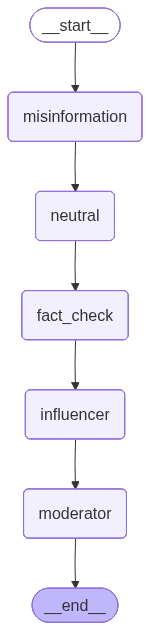

In [11]:
from IPython.display import Image, display

# Visualize the agent workflow graph
Image(graph.get_graph().draw_mermaid_png())


In [12]:

result = graph.invoke({})

print("  FINAL REPORT")
print(f"\n Original Claim:\n   {result.get('original_claim', 'N/A')}")
print(f"\n Influenced Content:\n   {result.get('influencer_content', 'N/A')}")
print(f"\n Verdict: {result.get('verdict', 'N/A')}")
print(f" Evidence: {result.get('evidence', 'N/A')}")
print(f" Amplification Score: {result.get('amplification_score', 0)}/10")
print(f" Moderation Decision: {result.get('moderation_decision', 'N/A')}")
print("\nRaw JSON:")
print(json.dumps(result, indent=2))

MISINFORMATION AGENT
Generated Claim: A recent study has found that widespread adoption of electric vehicles in major cities could reduce air pollution-related health problems by up to 25%. Researchers at a leading university analyzed data from several urban areas that have implemented EV-friendly infrastructure.
NEUTRAL AGENT
Sharing claim as-is: A recent study has found that widespread adoption of electric vehicles in major cities could reduce air pollution-related health problems by up to 25%. Researchers at a leading university analyzed data from several urban areas that have implemented EV-friendly infrastructure.
FACT-CHECKER AGENT
Claim: A recent study has found that widespread adoption of electric vehicles in major cities could reduce air pollution-related health problems by up to 25%. Researchers at a leading university analyzed data from several urban areas that have implemented EV-friendly infrastructure.
Verdict: Unverified
Evidence: The claim lacks specific details about t